<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana8/mostrando_plano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 711.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.0 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
AULA COMPARATIVA: PASCAL VOC vs. PADRÃO YOLO (CÓDIGO & MATEMÁTICA)
-> Carregando o modelo YOLOv8...
Digite o nome exato da imagem que você subiu (ex: minha_foto.jpg): relo.png
-> Analisando a imagem (304x418 pixels)...

RELATÓRIO TÉCNICO: COMPARAÇÃO DOS FORMATOS POR ALVO DETECTADO

Alvo 1 -> [CLOCK]
[Pascal VOC] Cantos (Pixels):      [Xmin: 66, Ymin: 136, Xmax: 222, Ymax: 285]
[YOLO Absoluto] Centro + Dimensões: [Xc: 144, Yc: 210, W: 155, H: 149]
[YOLO .txt] Gravado no disco:       [74 0.475339 0.504237 0.510075 0.357619]

[SUCESSO] Gráfico gerado! A janela comparativa será aberta.


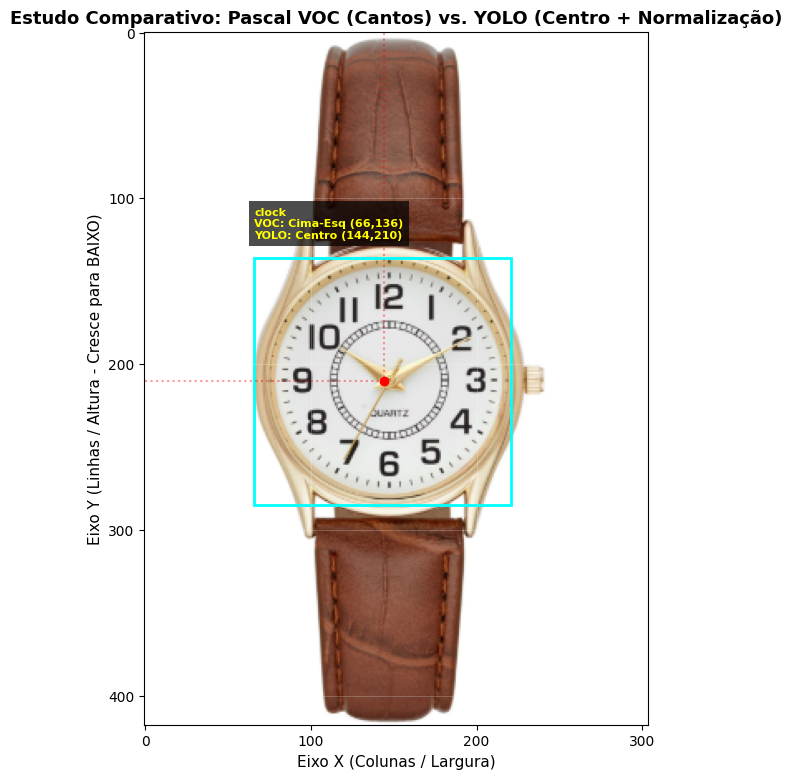

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

def comparar_formatos_bounding_boxes():
    print("="*75)
    print("AULA COMPARATIVA: PASCAL VOC vs. PADRÃO YOLO (CÓDIGO & MATEMÁTICA)")
    print("="*75)

    # 1. Carrega o modelo YOLOv8 padrão
    print("-> Carregando o modelo YOLOv8...")
    modelo = YOLO('yolov8n.pt')

    # 2. Pede para você digitar o nome do arquivo que subiu
    caminho_img = input("Digite o nome exato da imagem que você subiu (ex: minha_foto.jpg): ").strip()
    caminho_img = caminho_img.replace('"', '').replace("'", "")

    # Lendo a imagem com OpenCV
    img = cv2.imread(caminho_img)
    if img is None:
        print(f"[ERRO] Não foi possível encontrar o arquivo '{caminho_img}'. Verifique o nome.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    altura_img, largura_img, _ = img.shape

    # 3. Executando a predição na imagem enviada
    print(f"-> Analisando a imagem ({largura_img}x{altura_img} pixels)...")
    resultados = modelo.predict(source=caminho_img, conf=0.35, verbose=False)
    resultado = resultados[0]

    # 4. Configurando o gráfico com o plano cartesiano
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.imshow(img_rgb)

    print("\n" + "="*60)
    print("RELATÓRIO TÉCNICO: COMPARAÇÃO DOS FORMATOS POR ALVO DETECTADO")
    print("="*60)

    # 5. Iterando sobre os objetos para extrair os dois padrões
    for i, box in enumerate(resultado.boxes):
        classe_id = int(box.cls[0].item())
        nome_objeto = modelo.names[classe_id]

        # --- PADRÃO PASCAL VOC ---
        # Coordenadas absolutas dos cantos: [Xmin, Ymin, Xmax, Ymax]
        xmin, ymin, xmax, ymax = box.xyxy[0].cpu().numpy().astype(int)

        # --- PADRÃO YOLO (ABSOLUTO EM PIXELS) ---
        # Centro e dimensões em pixels: [X_centro, Y_centro, Largura, Altura]
        x_cent, y_cent, w_abs, h_abs = box.xywh[0].cpu().numpy().astype(int)

        # --- PADRÃO YOLO (NORMALIZADO PARA O ARQUIVO .TXT) ---
        # Valores proporcionais divididos pelas dimensões da tela (entre 0.0 e 1.0)
        x_norm, y_norm, w_norm, h_norm = box.xywhn[0].cpu().numpy()

        # Imprimindo a comparação detalhada no terminal para os alunos verem a matemática
        print(f"\nAlvo {i+1} -> [{nome_objeto.upper()}]")
        print(f"[Pascal VOC] Cantos (Pixels):      [Xmin: {xmin}, Ymin: {ymin}, Xmax: {xmax}, Ymax: {ymax}]")
        print(f"[YOLO Absoluto] Centro + Dimensões: [Xc: {x_cent}, Yc: {y_cent}, W: {w_abs}, H: {h_abs}]")
        print(f"[YOLO .txt] Gravado no disco:       [{classe_id} {x_norm:.6f} {y_norm:.6f} {w_norm:.6f} {h_norm:.6f}]")

        # --- VISUALIZAÇÃO GRÁFICA NA TELA ---
        # Desenha a caixa Pascal VOC (Retângulo ciano delimitando os cantos)
        retangulo = plt.Rectangle((xmin, ymin), w_abs, h_abs,
                                  fill=False, edgecolor='cyan', linewidth=2)
        ax.add_patch(retangulo)

        # Desenha o ponto central do YOLO (Ponto vermelho exato no meio do objeto)
        ax.plot(x_cent, y_cent, marker='o', color='red', markersize=6)

        # Linhas guias pontilhadas ligando o centro aos eixos cartesianos
        ax.vlines(x=x_cent, ymin=0, ymax=y_cent, color='red', linestyle='dotted', alpha=0.4)
        ax.hlines(y=y_cent, xmin=0, xmax=x_cent, color='red', linestyle='dotted', alpha=0.4)

        # Rótulo textual destacando a dualidade dos formatos
        texto_label = f"{nome_objeto}\nVOC: Cima-Esq ({xmin},{ymin})\nYOLO: Centro ({x_cent},{y_cent})"
        ax.text(xmin, max(0, ymin - 12), texto_label, color='yellow', fontsize=8, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))

    print("="*60)

    # 6. Estilizando o Grid e os Eixos Cartesianos
    plt.title("Estudo Comparativo: Pascal VOC (Cantos) vs. YOLO (Centro + Normalização)", fontsize=13, fontweight='bold')

    # Ativa a grade (grid) dividida em pixels
    ax.grid(color='white', linestyle='-', linewidth=0.5, alpha=0.3)

    # Define marcações nos eixos baseadas no tamanho real da imagem
    ax.set_xticks(np.arange(0, largura_img, 100))
    ax.set_yticks(np.arange(0, altura_img, 100))

    ax.set_xlabel("Eixo X (Colunas / Largura)", fontsize=11)
    ax.set_ylabel("Eixo Y (Linhas / Altura - Cresce para BAIXO)", fontsize=11)

    print("\n[SUCESSO] Gráfico gerado! A janela comparativa será aberta.")
    plt.show()

if __name__ == "__main__":
    comparar_formatos_bounding_boxes()